In [78]:
import os
import cv2
import sys
import random
import numpy as np
import matplotlib.pyplot as plt
from preprocess import Extractor
from circle_fit import taubinSVD

In [3]:
# instance of extractor
extractor = Extractor()
extractor.load_model()

# 1.extract roi

In [5]:
def rotateAndScale(img, scaleFactor = 0.5, degreesCCW = 30):
    '''
    rotate image with no cut out vertices
    Args:
        img: original image
        scaleFactor: scale of output image
        degreesCCW: angle (degrees)
    Return:
        rotateImg: rotated image
        M: rotate matrix
    '''
    h,w,c = img.shape #note: numpy uses (y,x) convention but most OpenCV functions use (x,y)
    M = cv2.getRotationMatrix2D(center=(w/2,h/2), angle=degreesCCW, scale=scaleFactor) #rotate about center of image.

    #choose a new image size.
    new_w,new_h = w*scaleFactor,h*scaleFactor
    #include this if you want to prevent corners being cut off
    r = np.deg2rad(degreesCCW)
    new_w,new_h = (abs(np.sin(r)*new_h) + abs(np.cos(r)*new_w),abs(np.sin(r)*new_w) + abs(np.cos(r)*new_h))

    #the warpAffine function call, below, basically works like this:
    # 1. apply the M transformation on each pixel of the original image
    # 2. save everything that falls within the upper-left "dsize" portion of the resulting image.

    #So I will find the translation that moves the result to the center of that region.
    (tx,ty) = ((new_w-w)/2,(new_h-h)/2)
    M[0,2] += tx #third column of matrix holds translation, which takes effect after rotation.
    M[1,2] += ty

    rotatedImg = cv2.warpAffine(img, M, dsize=(int(new_w),int(new_h)))
    return rotatedImg,M

In [6]:
def calc_dist(pt1,pt2):
    '''
    Calculate distance of 2 point
    Args:
        pt1: first point
        pt2: second point
    Return:
        dist: distance
    '''
    dist = cv2.norm(pt1-pt2)
    return dist

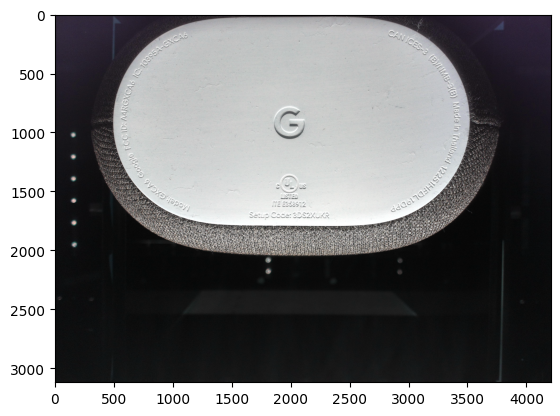

In [51]:
img_org = cv2.imread("Google Nest Audio.jpg")
img = img_org.copy()
plt.imshow(img)

In [52]:
# extract mask
mask = extractor.get_mask(img)

In [53]:
# find contours
contours, hierarchy = cv2.findContours(mask.astype("uint8"), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

In [54]:
# select suitable area
areas = []
for cnt in contours:
    area = cv2.contourArea(cnt)
    areas.append(area)

In [55]:
# select suitable area
cnts = []
s_min = np.array(areas).mean()
for cnt in contours:
    area = cv2.contourArea(cnt)
    if area > s_min:
        cnts.append(cnt)

(3104, 4192, 3)


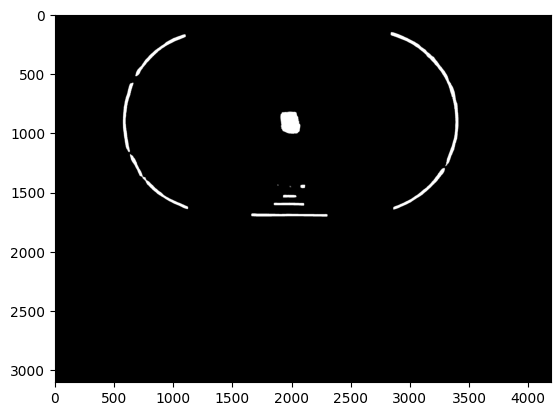

In [56]:
mask3 = cv2.merge([mask.astype("uint8"),mask.astype("uint8"),mask.astype("uint8")])
print(mask3.shape)
plt.imshow(mask3)

8
boxs 8


Text(0.5, 1.0, 'greater then mean rotated rectangle')

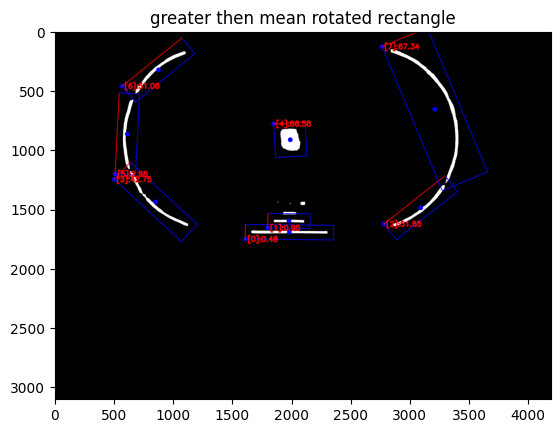

In [58]:
padding = 100
boxs = []
rects = []
angles = [] # degree
img = mask3.copy()
for i,cnt in enumerate(cnts):
    # roated rect (minimum rect)
    rect = cv2.minAreaRect(cnt)
    # angle
    angle = rect[-1]
    angles.append(angle)
    # new rect add padding
    h = int(rect[1][0]+ padding)
    w = int(rect[1][1]+ padding)
    new_rect = (rect[0],(h,w),angle) #h,w
    rects.append(new_rect)
    box = cv2.boxPoints(new_rect)
    box = np.int0(box)
    boxs.append(box)
    # draw
    cv2.drawContours(img,[box],0,(0,0,255),6) # min rect
    cv2.circle(img,(int(rect[0][0]),int(rect[0][1])),20,(0,0,255),-1)# top point
    cv2.circle(img,box[0],20,(0,0,255),-1)# top point
    cv2.line(img,box[0],box[1],(255,0,0),6)# top line
    cv2.putText(img,f"[{i}]:{round(angle,2)}",box[0]+np.array([20,20]),cv2.FONT_HERSHEY_SIMPLEX,2,(255,0,0),10, cv2.LINE_AA) # angle

print(len(boxs))
print(f"boxs {len(boxs)}")
plt.imshow(img)
plt.title("greater then mean rotated rectangle")

In [72]:
rois = []
masks = []

for i,t in enumerate(angles):
    # original input
    img = img_org.copy()
    img_mask = mask3.copy()
    rect = rects[i]
    box = boxs[i] # 4 pts form of rect
    rebox = box.reshape(-1,1,2)
    #rotate
    img,M = rotateAndScale(img, scaleFactor = 2.0, degreesCCW = t)
    img_mask,_ = rotateAndScale(img_mask, scaleFactor = 2.0, degreesCCW = t)
    rebox = cv2.transform(rebox, M) # what you need
    # find new top left,bottom right
    dist = []
    for pt in rebox.reshape(-1,2):
        d = calc_dist(np.array([0,0]),pt)
        dist.append(d)
    top_left = rebox.reshape(-1,2)[np.argmin(dist)]
    bottom_right = rebox.reshape(-1,2)[np.argmax(dist)]
    w,h = bottom_right - top_left
    x,y = top_left
    out = img[y:y+h,x:x+w]
    out_m = img_mask[y:y+h,x:x+w]
    rois.append(out)
    masks.append(out_m)

In [73]:
for i,roi in enumerate(rois):
    h,w,c = roi.shape
    if h > w:
        roi = cv2.rotate(roi,cv2.ROTATE_90_CLOCKWISE)
        rois[i]=roi

In [74]:
for i,mask in enumerate(masks):
    h,w,c = mask.shape
    if h > w:
        mask = cv2.rotate(mask,cv2.ROTATE_90_CLOCKWISE)
        masks[i]=mask

<Figure size 640x480 with 0 Axes>

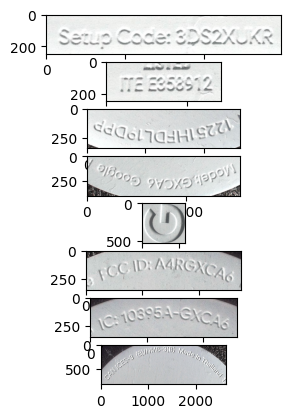

In [75]:
plt.figure()

fig,ax = plt.subplots(len(rois),1)
for i in range(len(rois)):
    ax[i].imshow(rois[i])

<Figure size 640x480 with 0 Axes>

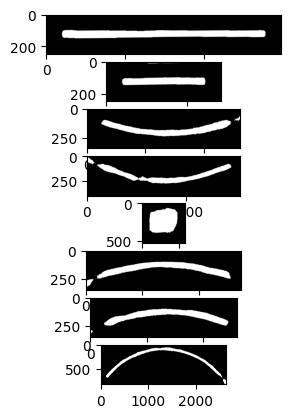

In [76]:
plt.figure()

fig,ax = plt.subplots(len(masks),1)
for i in range(len(masks)):
    ax[i].imshow(masks[i])

# 2.fit-in circle

(828, 2635)


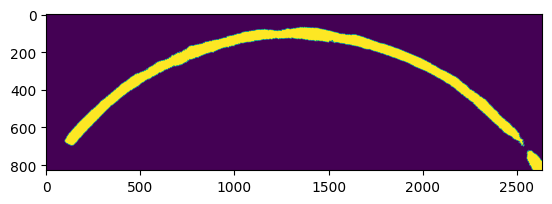

In [239]:
idx=-1
mask = masks[idx]
mask = cv2.cvtColor(mask,cv2.COLOR_BGR2GRAY)
h,w = mask.shape
print(mask.shape)
plt.imshow(mask)

In [240]:
curve = []
for i in range(w):
    v_line = mask[:,i:i+1]
    pos = cv2.findNonZero(v_line)
    if pos is not None:
        curve.append((pos[0][0][1],i))

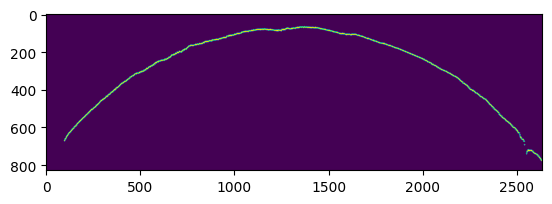

In [241]:
blank = np.zeros_like(mask)
for point in curve:
    cv2.circle(blank,(point[1], point[0]), 3, (255,255,255), -1)
plt.imshow(blank)

In [242]:
xc, yc, r, sigma = taubinSVD(curve)
print(f"xc={int(xc)}, yc={int(yc)}, r={int(r)}, sigma={sigma}") #217330,1739

xc=1632, yc=1314, r=1556, sigma=4.315036621714274


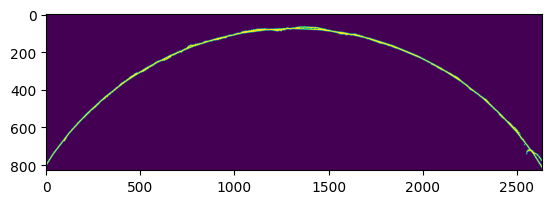

In [243]:
cv2.circle(blank, (int(yc),int(xc)), int(r), (255), 6)
plt.imshow(blank)

# 3.wrap roi

In [244]:
r = int(r)

(3112, 3112, 3)


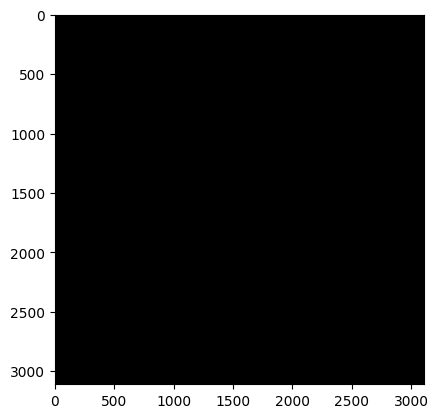

In [245]:
blank = np.zeros((r*2,r*2,3))
blank = blank.astype(np.uint8)
print(blank.shape)
plt.imshow(blank)

In [246]:
x = int(r - w/2)
y = 0

In [247]:
x2 = x+w
y2 = h

In [248]:
blank[y:y2,x:x2].shape

(828, 2635, 3)

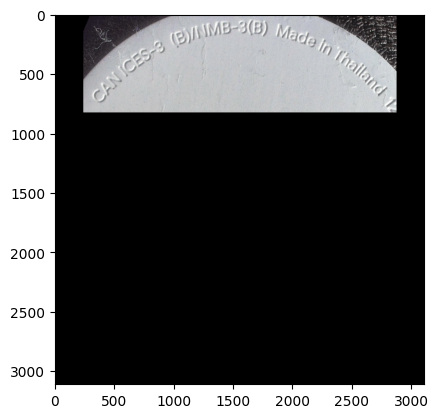

In [249]:
blank[y:y2,x:x2]=rois[idx]
plt.imshow(blank)

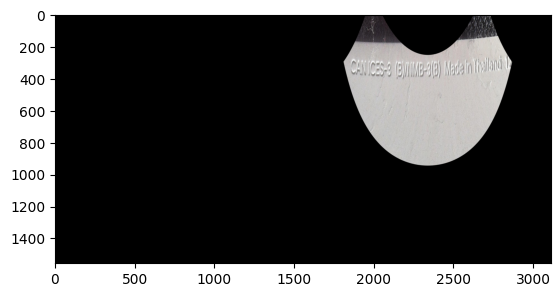

In [250]:
flags = cv2.INTER_CUBIC + cv2.WARP_FILL_OUTLIERS + cv2.WARP_POLAR_LINEAR
polar_img = cv2.warpPolar(blank,(r,r*2),(r,r),r+300,flags) # w,h
out = polar_img.transpose(1,0,2)[::-1]
plt.imshow(cv2.cvtColor(out,cv2.COLOR_BGR2RGB))

In [251]:
h,w,c=out.shape

In [252]:
y_list = []
for i in range(h):
    h_line = out[i:i+1,:]
    if np.sum(h_line) != 0:
        y_list.append(i)

y0=y_list[0]
y1=y_list[-1]
print(f"y0={y0},y1={y1}")

y0=0,y1=944


In [253]:
x_list = []
for i in range(w):
    v_line = out[:,i:i+1]
    if np.sum(v_line) != 0:
        x_list.append(i)
x0=x_list[0]
x1=x_list[-1]
print(f"x0={x0},x1={x1}")

x0=1806,x1=2861


True

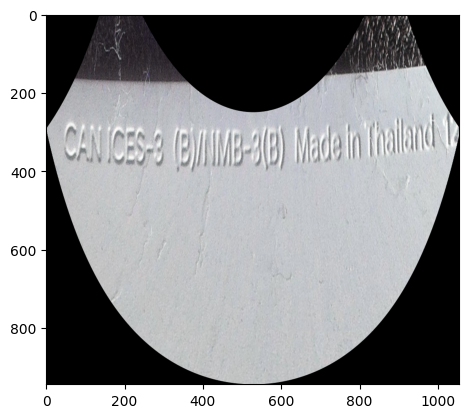

In [254]:
out = out[y_list[0]:y_list[-1],x_list[0]:x_list[-1]]
plt.imshow(out)
cv2.imwrite("out.jpg",out)